In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib Inline
%config IlineBackend.figure_format = "svg"

**Построение модели классификации**
1. Обзор обучающего датасета
2. Обработка выбросов
3. Обработка пропусков
4. Анализ данных
5. Отбор признаков
6. Подбор моделей, получение бейзлана
7. Проверка качества, борьба с переобучением
8. Интерпретация результатов

In [16]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

## 1. Обзор обучающего датасета

In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   10000 non-null  int64  
 1   age                  10000 non-null  float64
 2   years_of_experience  10000 non-null  float64
 3   lesson_price         10000 non-null  float64
 4   qualification        10000 non-null  float64
 5   physics              10000 non-null  float64
 6   chemistry            10000 non-null  float64
 7   biology              10000 non-null  float64
 8   english              10000 non-null  float64
 9   geography            10000 non-null  float64
 10  history              10000 non-null  float64
 11  mean_exam_points     10000 non-null  float64
 12  choose               10000 non-null  int64  
dtypes: float64(11), int64(2)
memory usage: 1015.8 KB


* **Id** - unique identifier
* **age** - Age of tutor
* **years_of_experience**
* **lesson_price**
* **qualification**
* **physics** - teaches physics
* **chemistry** - teaches chemistry
* **biology** - teaches biology
* **english** - teaches english
* **geography** - teaches geography
* **history** - teaches history
* **mean_exam_points**
* **choose** - target

In [11]:
df_train.describe()

,Id,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,4999.50000,45.800900,1.974800,1702.440000,1.724300,0.37060,0.121500,0.117200,0.059100,0.02770,0.018000,64.435200,0.110900
std,2886.89568,8.030274,1.766883,523.789062,0.798845,0.48299,0.326724,0.321675,0.235824,0.16412,0.132958,13.595024,0.314024
min,0.00000,23.000000,0.000000,200.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,33.000000,0.000000
25%,2499.75000,40.000000,0.000000,1300.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,55.000000,0.000000
50%,4999.50000,46.000000,2.000000,1550.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,63.000000,0.000000
75%,7499.25000,51.000000,3.000000,2150.000000,2.000000,1.00000,0.000000,0.000000,0.000000,0.00000,0.000000,74.000000,0.000000
max,9999.00000,68.000000,9.000000,3950.000000,4.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,100.000000,1.000000


At first sight everything is clear. There are no Null elements in features, min and max values apear to be right (no outliers in the data). There are only two types of data. First is int64 type float64. Should think about reducing memory usage.


Continue investigate the data.

In [18]:
df_train.head()

,Id,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
0,0,35.0,0.0,2150.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,74.0,0
1,1,52.0,2.0,1250.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,57.0,1
2,2,29.0,3.0,1750.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,66.0,0
3,3,33.0,3.0,1050.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,66.0,1
4,4,46.0,3.0,2250.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,73.0,0


In [19]:
df_test.head()

,Id,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points
0,10000,32.0,2.0,2700.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,90.0
1,10001,35.0,6.0,1800.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,71.0
2,10002,44.0,2.0,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0
3,10003,44.0,4.0,2950.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,92.0
4,10004,38.0,3.0,1400.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,58.0


## Continuous variables

In [84]:
def measures_of_the_central_trend(data: pd.Series):
    mean_ = data.mean()
    median_ = data.median()
    mode_ = data.mode()[0]
    return mean_, median_, mode_

### Age

In [85]:
age_mean, age_median, age_mode = measures_of_the_central_trend(df_train["age"])
print(f"Measures of the central trend for Age:\nMean - {age_mean}\nMode - {age_mode}\nMedian - {age_median}")

Measures of the central trend for Age:
Mean - 45.8009
Mode - 44.0
Median - 46.0


<Figure size 300x300 with 0 Axes>

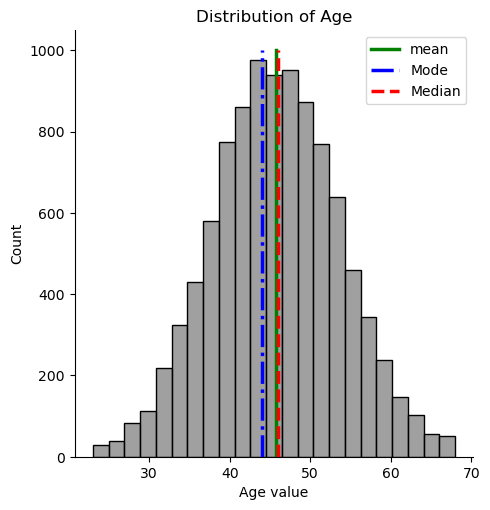

In [98]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1000, 1000)
sns.displot(df_train["age"], bins=23, color="grey", kde=False)
plt.plot([age_mean] * 1000, y, color="green", linewidth=2.5, label="mean")
plt.plot([age_mode] * 1000, y, color="blue", linewidth=2.5, label="Mode", linestyle="-.")
plt.plot([age_median] * 1000, y, color="red", linewidth=2.5, label="Median", linestyle="dashed")

plt.title("Distribution of Age")
plt.ylabel("Count")
plt.xlabel("Age value")
plt.legend(loc="upper right")

plt.show()

### Lesson price

In [87]:
lesson_price_mean, lesson_price_median, lesson_price_mode = measures_of_the_central_trend(df_train["lesson_price"])
print(f"Measures of the central trend for lesson_price:\nMean - {lesson_price_mean}\nMode - {lesson_price_mode}\nMedian - {lesson_price_median}")

Measures of the central trend for lesson_price:
Mean - 1702.44
Mode - 1450.0
Median - 1550.0


<Figure size 300x300 with 0 Axes>

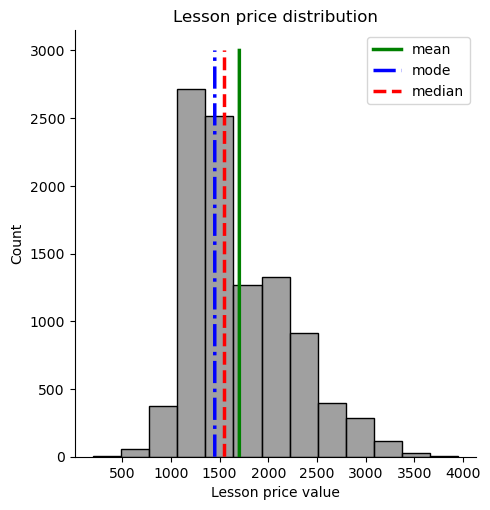

In [104]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 3000, 3000)
sns.displot(df_train["lesson_price"], bins=13, color="grey", kde=False)
plt.plot([lesson_price_mean] * 3000, y, color="green", linewidth=2.5, label="mean")
plt.plot([lesson_price_mode] * 3000, y, color="blue", linewidth=2.5, linestyle="-.", label="mode")
plt.plot([lesson_price_median] * 3000, y, color="red", linewidth=2.5, linestyle="dashed", label="median")

plt.title("Lesson price distribution")
plt.ylabel("Count")
plt.xlabel("Lesson price value")
plt.legend(loc="upper right")

plt.show()

### Mean exam points

In [128]:
mean_exam_points_mean, mean_exam_points_median, mean_exam_points_mode = measures_of_the_central_trend(df_train["mean_exam_points"])
print(
    f"Measures of the central trend for mean_exam_points_:\nMean - {mean_exam_points_mean}\nMode - {mean_exam_points_mode}\nMedian - "\
    f"{mean_exam_points_median}"
)

Measures of the central trend for mean_exam_points_:
Mean - 64.4352
Mode - 62.0
Median - 63.0


<Figure size 300x300 with 0 Axes>

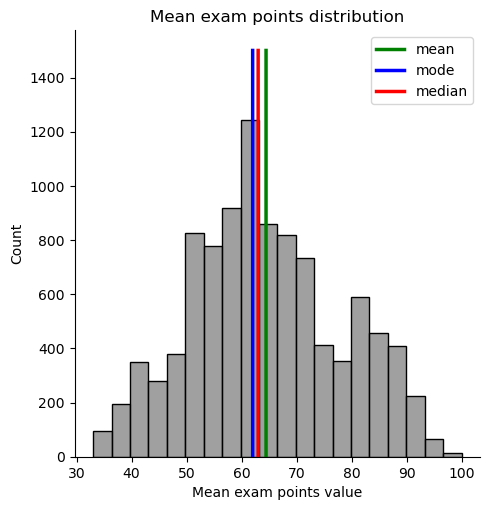

In [127]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1500, 1500)
sns.displot(df_train["mean_exam_points"], bins=20, color="grey", kde=False)
plt.plot([mean_exam_points_mean] * 1500, y, color="green", linewidth=2.5, label="mean")
plt.plot([mean_exam_points_mode] * 1500, y, color="blue", linewidth=2.5, label="mode")
plt.plot([mean_exam_points_median] * 1500, y, color="red", linewidth=2.5, label="median")

plt.title("Mean exam points distribution")
plt.ylabel("Count")
plt.xlabel("Mean exam points value")
plt.legend(loc="upper right")

plt.show()

According to the histogram, distributions of Age and Mean exam points tend to be normal, at the same time Lesson prise distribution has Asymmetrically type of distribution. Max point of exam do not exceed 100 and min point value is above zero.

The Age of Majority's tutors placed between 40 and 50. Mode and mean values are almost identical 44.0, 45.8 respectively, therefore this distribution realy tends to be normal.

Measures of the central trend for Mean exam points are quite close to each other (62, 63, 64.4)

The most popular Lesson prices located between 1100 and 1500. The biggest price is 4000, the smallest is 200. So now, this data is apears to be clear